# **Travail pratique 2 SDD1001**


---



# **Par : Yannick Poirier**



---



# **Début de la partie 1 : Manipulation des Données avec Pandas**

Imports nécéssaire à exécuter avant tout :

In [ ]:
import requests
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler
from io import StringIO
import os
import unittest

**Charger un jeu de données CSV contenant des informations sur des villes, comprenant les colonnes ville, pays, population, latitude et longitude**

Cette partie importe le fichier fichier .csv nécessaire au fonctionnement de l'application. Il va lire le fichier sur mon google drive et le rendre accessible. Les 5 premiers éléments du fichier sont afficher pour être certain qu'il est bien lu.

In [ ]:
#https://drive.google.com/file/d/1Oytomiaxf4n3JvX0JMYtw9GUcbZ3S98d/view?usp=sharing ville.csv
file_id = '1Oytomiaxf4n3JvX0JMYtw9GUcbZ3S98d'
direct_link = f'https://drive.google.com/uc?id={file_id}'

response = requests.get(direct_link)
response.raise_for_status()  # Une erreur est soulevé si jamais il y a un problème dans chargement fichier donnees.csv
data = response.content.decode('utf-8') # Décode les bits pour permettre affichage

df = pd.read_csv(StringIO(data)) # Pandas va lire le fichier décodé
print(df.head().to_string(index=False)) # Affichage des 5 premières entrées dans la base de données sans tabulation pour être sur que tout est ok

    ville  latitude  longitude      pays  population
    Tokyo   35.6897   139.6922     Japan  37732000.0
  Jakarta   -6.1750   106.8275 Indonesia  33756000.0
    Delhi   28.6100    77.2300     India  32226000.0
Guangzhou   23.1300   113.2600     China  26940000.0
   Mumbai   19.0761    72.8775     India  24973000.0




---



**Nettoyer les données en traitant les valeurs manquantes et en filtrant les données incorrectes.**

Cette partie vérifie s'il y a des données manquantes dans le jeu de données à l'aide de certaines fonctions de base. On remarque qu'il manque une donnée à latitude, longitude, pays et population.

In [ ]:
df.info() # Informations de base sur les données (nom, valeurs manquantes et type)
df.isna().sum() # Somme des valeurs manquantes pour chaque colonne

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ville       100 non-null    object 
 1   latitude    99 non-null     float64
 2   longitude   99 non-null     float64
 3   pays        99 non-null     object 
 4   population  99 non-null     float64
dtypes: float64(3), object(2)
memory usage: 4.0+ KB


,0
ville,0
latitude,1
longitude,1
pays,1
population,1




---



Pour gérer les valeurs manquantes, j'ai remarqué que les valeurs affectés sont des variables continues (latitude, longitude, population) et catégorielles (pays). Puisque les données manquantes sont minimes, j'ai trouvé ou était le problème : toute les données manquantes se trouvent dans la ligne 8. En fait, je remarque aussi que les données pour chaque colonnes sont présente, mais elle ont toute été insérées dans ville. Dans ce contexte, ville = Seoul, Latitude = 37.5600, Longitude = 126.9900, Pays = "Korea, South", Population = 23016000

In [ ]:
# Trouver les lignes avec des données manquantes
print("\nLignes avec des données manquantes :")
print(df[df.isnull().any(axis=1)])


Lignes avec des données manquantes :
                                            ville  latitude  longitude pays  \
8  Seoul,37.5600,126.9900,"Korea, South",23016000       NaN        NaN  NaN   

   population  
8         NaN  




---



Cette partie va assigner les valeurs correspondantes aux bonnes colonnes pour résoudre le problème. Je modifie également le nom de la ville, car de la façon que le nom est saisie, le nom de la ville à l'index 8 est : Seoul,37.5600,126.9900,"Korea, South",23016000 ce qui est une erreur, mais pas détecter car des informations sont insérer et ce n'est donc pas une valeur nulle.

In [ ]:
# Ligne 8 dans l'index à corriger
ligne_a_corriger = 8

# Les bonnes données réelles qu'on veut insérer
corrections = {
    "ville": "Seoul",
    "latitude": 37.5600,
    "longitude": 126.9900,
    "pays": "Korea, South",
    "population": 23016000
}

# Appliquer les corrections à l'aide de loc
df.loc[ligne_a_corriger, "ville"] = corrections["ville"]
df.loc[ligne_a_corriger, "latitude"] = corrections["latitude"]
df.loc[ligne_a_corriger, "longitude"] = corrections["longitude"]
df.loc[ligne_a_corriger, "pays"] = corrections["pays"]
df.loc[ligne_a_corriger, "population"] = corrections["population"]

# Afficher le df corrigé
print(df.loc[8])

ville                Seoul
latitude             37.56
longitude           126.99
pays          Korea, South
population      23016000.0
Name: 8, dtype: object




---



Je m'assure ensuite qu'il n'y a plus d'erreur de valeur nulle avec les mêmes méthodes. Ont voit maintenant que les valeurs nulles sont de 0 pour toutes les colonnes.

In [ ]:
df.info() # Informations de base sur les données (nom, valeurs manquantes et type)
df.isna().sum() # Somme des valeurs manquantes pour chaque colonne

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ville       100 non-null    object 
 1   latitude    100 non-null    float64
 2   longitude   100 non-null    float64
 3   pays        100 non-null    object 
 4   population  100 non-null    float64
dtypes: float64(3), object(2)
memory usage: 4.0+ KB


,0
ville,0
latitude,0
longitude,0
pays,0
population,0




---



Je m'assure ensuite que le reste de mes données sont normales et qu'il n'y a pas de doublons ou de valeur abhérente selon une cohérence logique. Je me rend compte qu'il n'y a pas de valeur abhérente et que les données sont normales.

In [ ]:
print("\nNombre de doublons :")
print(df.duplicated().sum()) # Somme des doublons s'il y en a (une ligne identique à une autre)

print("\nLatitude abhérente (aucune si liste vide) : ")
print(df[(df['latitude'] < -90) | (df['latitude'] > 75)])  # Latitude invalide si pas inclus entre -90 et 90

print("\nLongitude abhérente (aucune si liste vide) : ")
print(df[(df['longitude'] < -180) | (df['longitude'] > 150)])  # Longitude invalide si pas inclus entre -180 et 180

print("\nPopulation abhérente :")
print(df[df['population'] <= 5000])  # Population invalide si moins de 5000 habitant

print("\nPays mentionnés dans la base de données (avec leur fréquence) :")
print(df['pays'].value_counts()) # Affiche les pays uniques et le nombre de fois qu'ils apparaissent dans le df. Un pays peut avoir plusieurs villes.

print("\nVilles qui apparaissent plus d'une fois (aucune si liste vide) :")
villes_double = df['ville'].value_counts()[df['ville'].value_counts() > 1] # Ville invalide si mentionné plus d'une fois, car chaque ville doit être unique. Une ville ne peut pas avoir plusieurs pays.
print(villes_double)


Nombre de doublons :
0

Latitude abhérente (aucune si liste vide) : 
Empty DataFrame
Columns: [ville, latitude, longitude, pays, population]
Index: []

Longitude abhérente (aucune si liste vide) : 
Empty DataFrame
Columns: [ville, latitude, longitude, pays, population]
Index: []

Population abhérente :
Empty DataFrame
Columns: [ville, latitude, longitude, pays, population]
Index: []

Pays mentionnés dans la base de données (avec leur fréquence) :
pays
China               45
India                9
United States        6
Japan                3
Brazil               2
Indonesia            2
Vietnam              2
Bangladesh           2
Pakistan             2
Tanzania             1
Malaysia             1
South Africa         1
Colombia             1
Saudi Arabia         1
Sudan                1
Hong Kong            1
Peru                 1
Chile                1
Spain                1
Iraq                 1
Singapore            1
Angola               1
Iran                 1
France        



---



**Calculer des statistiques descriptives sur la population des villes.**

Voici maintenant des statistiques desriptives sur la population des villes. Dans un premier temps, on peut voir un graphique à bande et une boite à moustache pandas très simple qui introduit la fréquence de répartition des populations selon les différents pays. On peut ainsi visualiser la distribution de population et la fréquence.

count    1.000000e+02
mean     1.161996e+07
std      6.643039e+06
min      5.708191e+06
25%      6.993809e+06
50%      8.998014e+06
75%      1.476525e+07
max      3.773200e+07
Name: population, dtype: float64

Analyse de la colonne : population
Valeur minimale : 5708191.0
Valeur maximale : 37732000.0
Moyenne : 11619961.80
Médiane : 8998014.50
Mode : 5708191.0


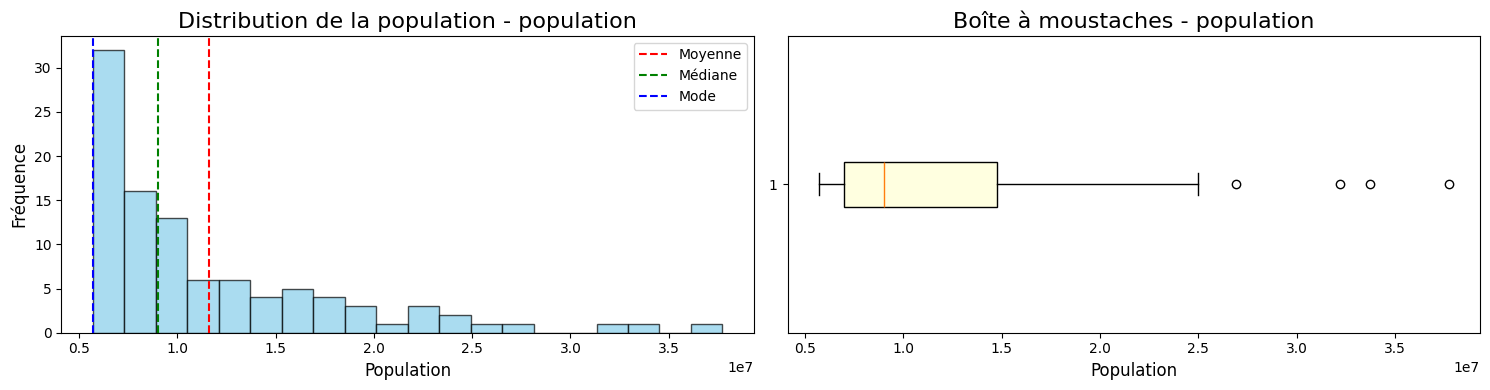

In [ ]:
# Statistiques descriptives
print(df['population'].describe()) # Statistiques descriptives

col = 'population' # Analyse de la colonne population

# Afficher les statistiques descriptives
print(f"\nAnalyse de la colonne : {col}")
print(f"Valeur minimale : {df[col].min()}") # Population la plus basse
print(f"Valeur maximale : {df[col].max()}") # Population la plus haute
print(f"Moyenne : {df[col].mean():.2f}") # Population moyenne
print(f"Médiane : {df[col].median():.2f}") # Population médianne
print(f"Mode : {df[col].mode()[0]}") # Mode de la population

plt.figure(figsize=(15, 4))  # Taille globale de la figure

# Créer histogramme
plt.subplot(1, 2, 1) # Nombre ligne dans grille, nombre colonnes grille, index sous-graphique dans grille
plt.hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black', alpha=0.7) # Barres du graph
plt.axvline(df[col].mean(), color='red', linestyle='--', label='Moyenne') # Ligne de la moyenne
plt.axvline(df[col].median(), color='green', linestyle='--', label='Médiane') # Ligne de la médiane
plt.axvline(df[col].mode()[0], color='blue', linestyle='--', label='Mode') # Ligne du mode
plt.title(f"Distribution de la population - {col}", fontsize=16) # Titre graph
plt.xlabel("Population", fontsize=12) # Titre axe x
plt.ylabel("Fréquence", fontsize=12) # Titre axe y
plt.legend() # Affiche la légende

# Créer boite à moustaches (boxplot)
plt.subplot(1, 2, 2) # Nombre ligne dans grille, nombre colonnes grille, index sous-graphique dans grille
plt.boxplot(df[col].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor="lightyellow")) # Création de la boite
plt.title(f"Boîte à moustaches - {col}", fontsize=16) # Titre graph
plt.xlabel("Population", fontsize=12) # Titre axe x
plt.ylabel("") # Titre axe y

plt.tight_layout() # Ajuster les espacements pour éviter les chevauchements
plt.show() # Affiche figures



---



Dans un deuxième temps, nous avons un graphique de diagramme à barre horizontales qui illustre tout les pays du df avec la population (une somme de toute les villes appartenant au pays est calculé). Ont peut ainsi voir les noms de pays avec la plus grande population jusqu'à la plus petite. Le deuxième digramme est exactement le mêmme principe, mais avec le top 20 des villes. Donc, les 20 villes les plus peuplés sont affichés.

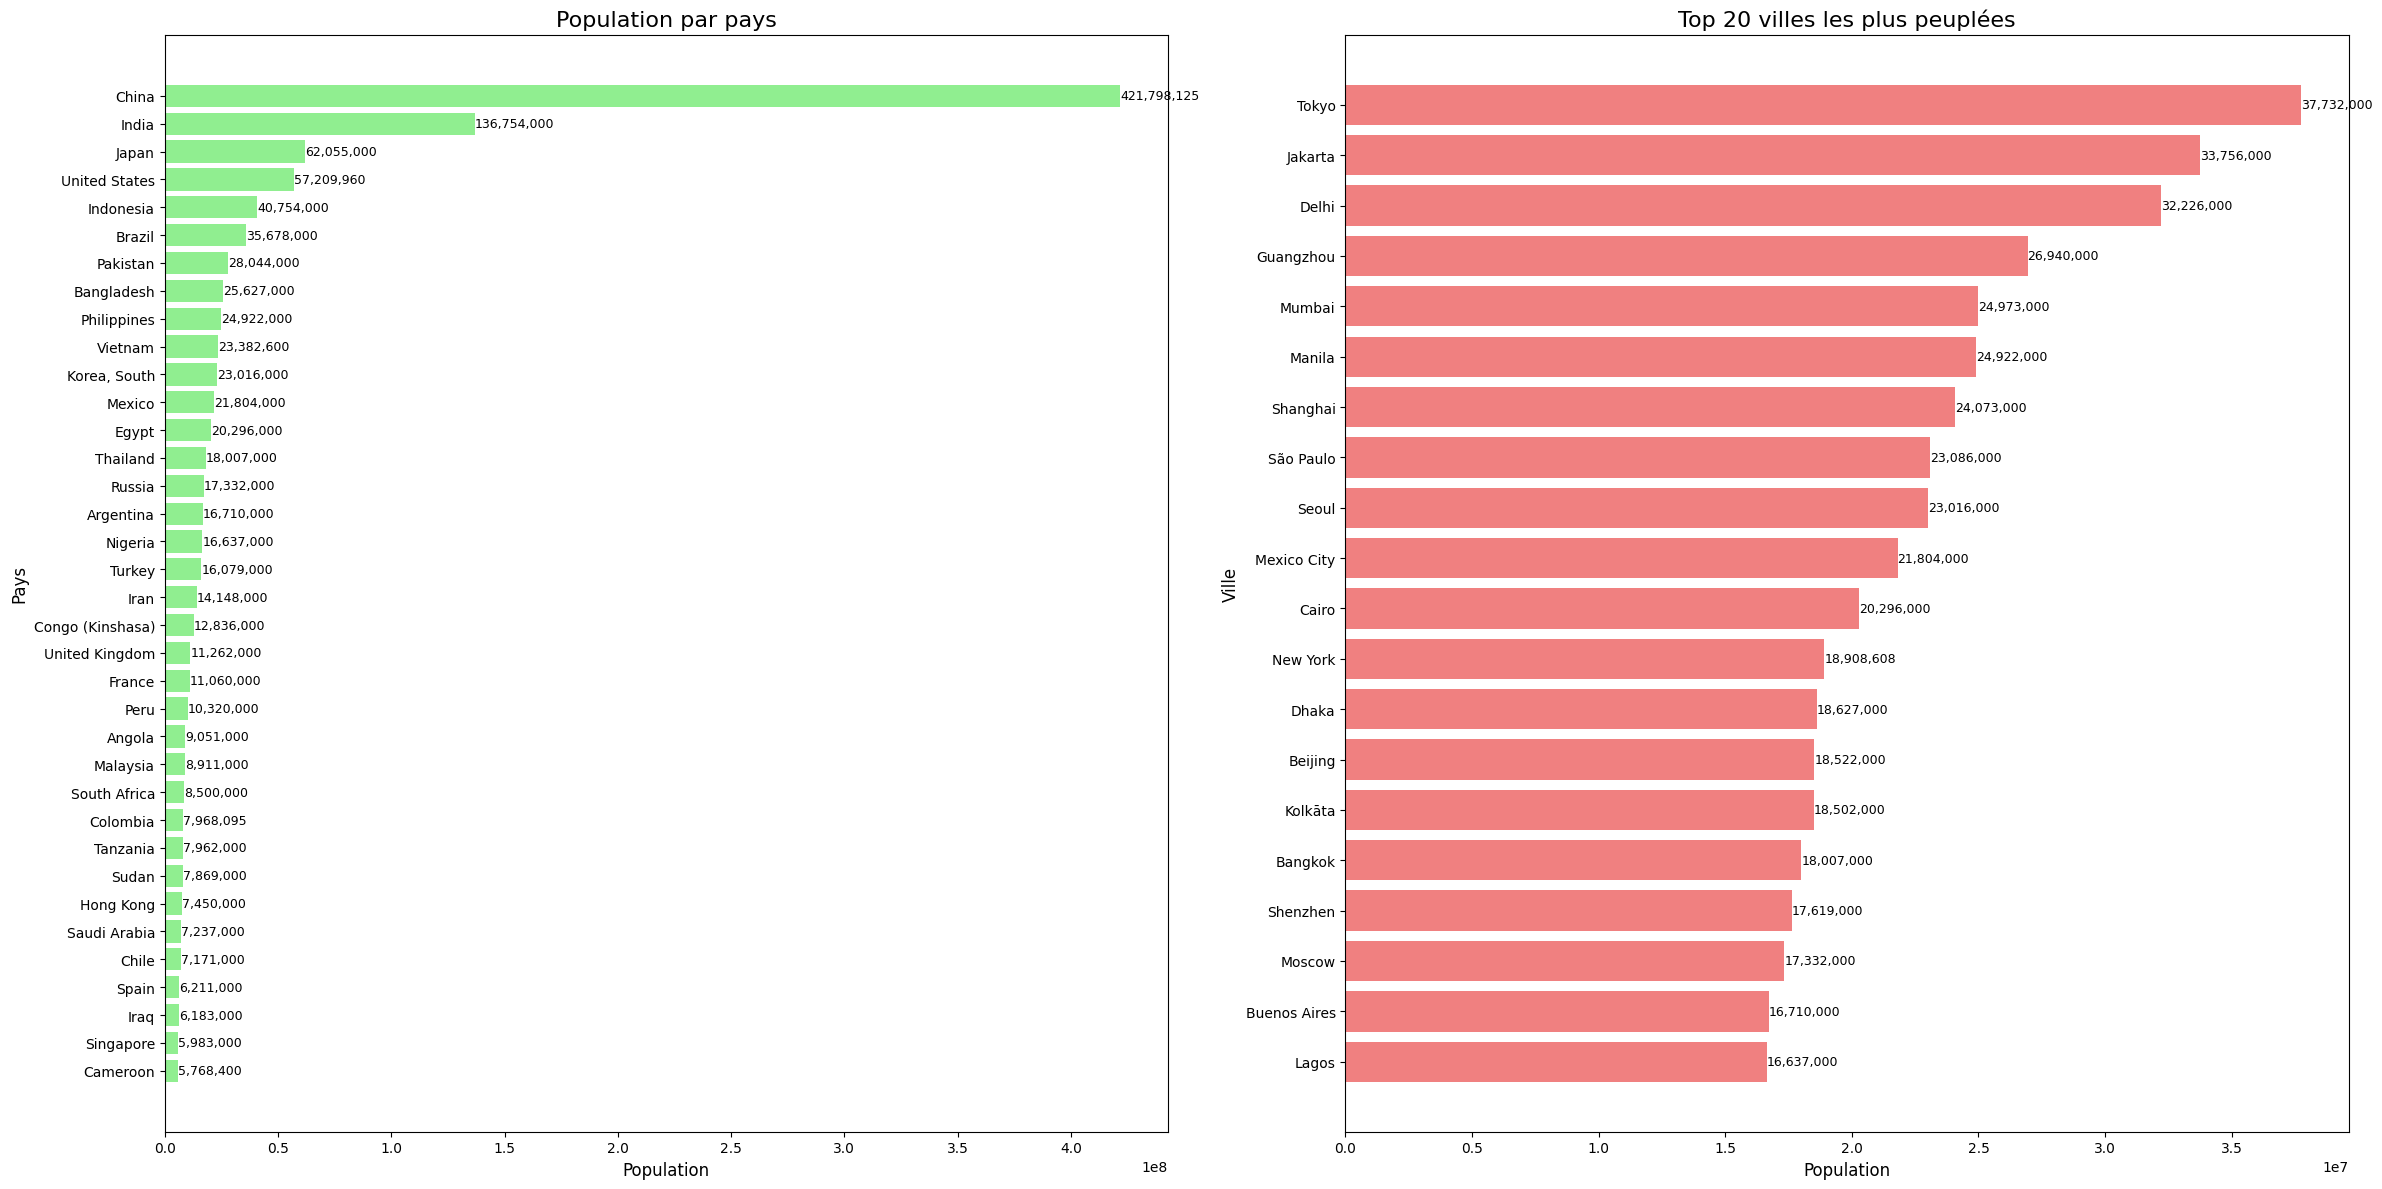

In [ ]:
# Préparation des données par pays
data_pays = (
    df.groupby('pays', as_index=False)['population']  # Groupement par pays sans utiliser le pays comme index
    .sum()  # Somme des populations pour chaque pays
    .sort_values(by='population', ascending=False)  # Trier les pays par population décroissante
)

# Préparation des données pour les villes
data_villes = (
    df[['ville', 'population']]  # Sélectionner les colonnes 'ville' et 'population'
    .sort_values(by='population', ascending=False)  # Trier les villes par population décroissante
    .head(20)  # Prendre les 20 villes les plus peuplées pour faire un top 20, car sinon trop de ville à afficher
)

# Création de la figure avec deux graphiques côte à côte
plt.figure(figsize=(24, 12))  # Taille de la figure

# Graphique 1 : Population par pays
plt.subplot(1, 2, 1)  # Nombre ligne dans grille, nombre colonnes grille, index sous-graphique dans grille (position 1)
plt.barh(data_pays['pays'], data_pays['population'], color='lightgreen')  # Diagramme à barres horizontales pour la population par pays
for i, value in enumerate(data_pays['population']): # Ajoute population en chiffre sur chaque barre pour une meilleure lisibilité
    plt.text(value, i, f'{value:,.0f}', va='center', fontsize=9)  # Afficher la population pour chaque barre
plt.xlabel('Population', fontsize=12)  # Titre axe x
plt.ylabel('Pays', fontsize=12)  # Titre axe y
plt.title('Population par pays', fontsize=16)  # Titre graph
plt.gca().invert_yaxis()  # Inverser l'axe des y pour afficher les pays les plus peuplés en haut

# Graphique 2 : Top 20 villes les plus peuplées
plt.subplot(1, 2, 2)  # Nombre ligne dans grille, nombre colonnes grille, index sous-graphique dans grille (position 2)
plt.barh(data_villes['ville'], data_villes['population'], color='lightcoral')  # Diagramme à barres horizontales pour la population par ville
for i, value in enumerate(data_villes['population']): # Ajoute population en chiffre sur chaque barre pour une meilleure lisibilité
    plt.text(value, i, f'{value:,.0f}', va='center', fontsize=9)  # Afficher la population pour chaque barre

plt.xlabel('Population', fontsize=12)  # Titre axe x
plt.ylabel('Ville', fontsize=12)  # Titre axe y
plt.title('Top 20 villes les plus peuplées', fontsize=16)  # Titre graph
plt.gca().invert_yaxis()  # Inverser l'axe des y pour afficher les villes les plus peuplées en haut

# Optimisation de l'affichage
plt.tight_layout()  # Ajuster les espacements pour éviter les chevauchements
plt.show()  # Afficher les graphiques



---



Dans un troisième temps, il est évidemment possible d'effectuer des statistiques descriptives sur la population d'un pays en particulier et ses villes. Nous allons en explorer 1, la chine, puisque c'est le pays avec la population la plus élévé (421.8m) et le nombre de villes le plus élévé aussi (45). Le graphique montre la répartition de la population chinoise en % selon chacune des villes et présente des opérations de base comme l'écart-type.

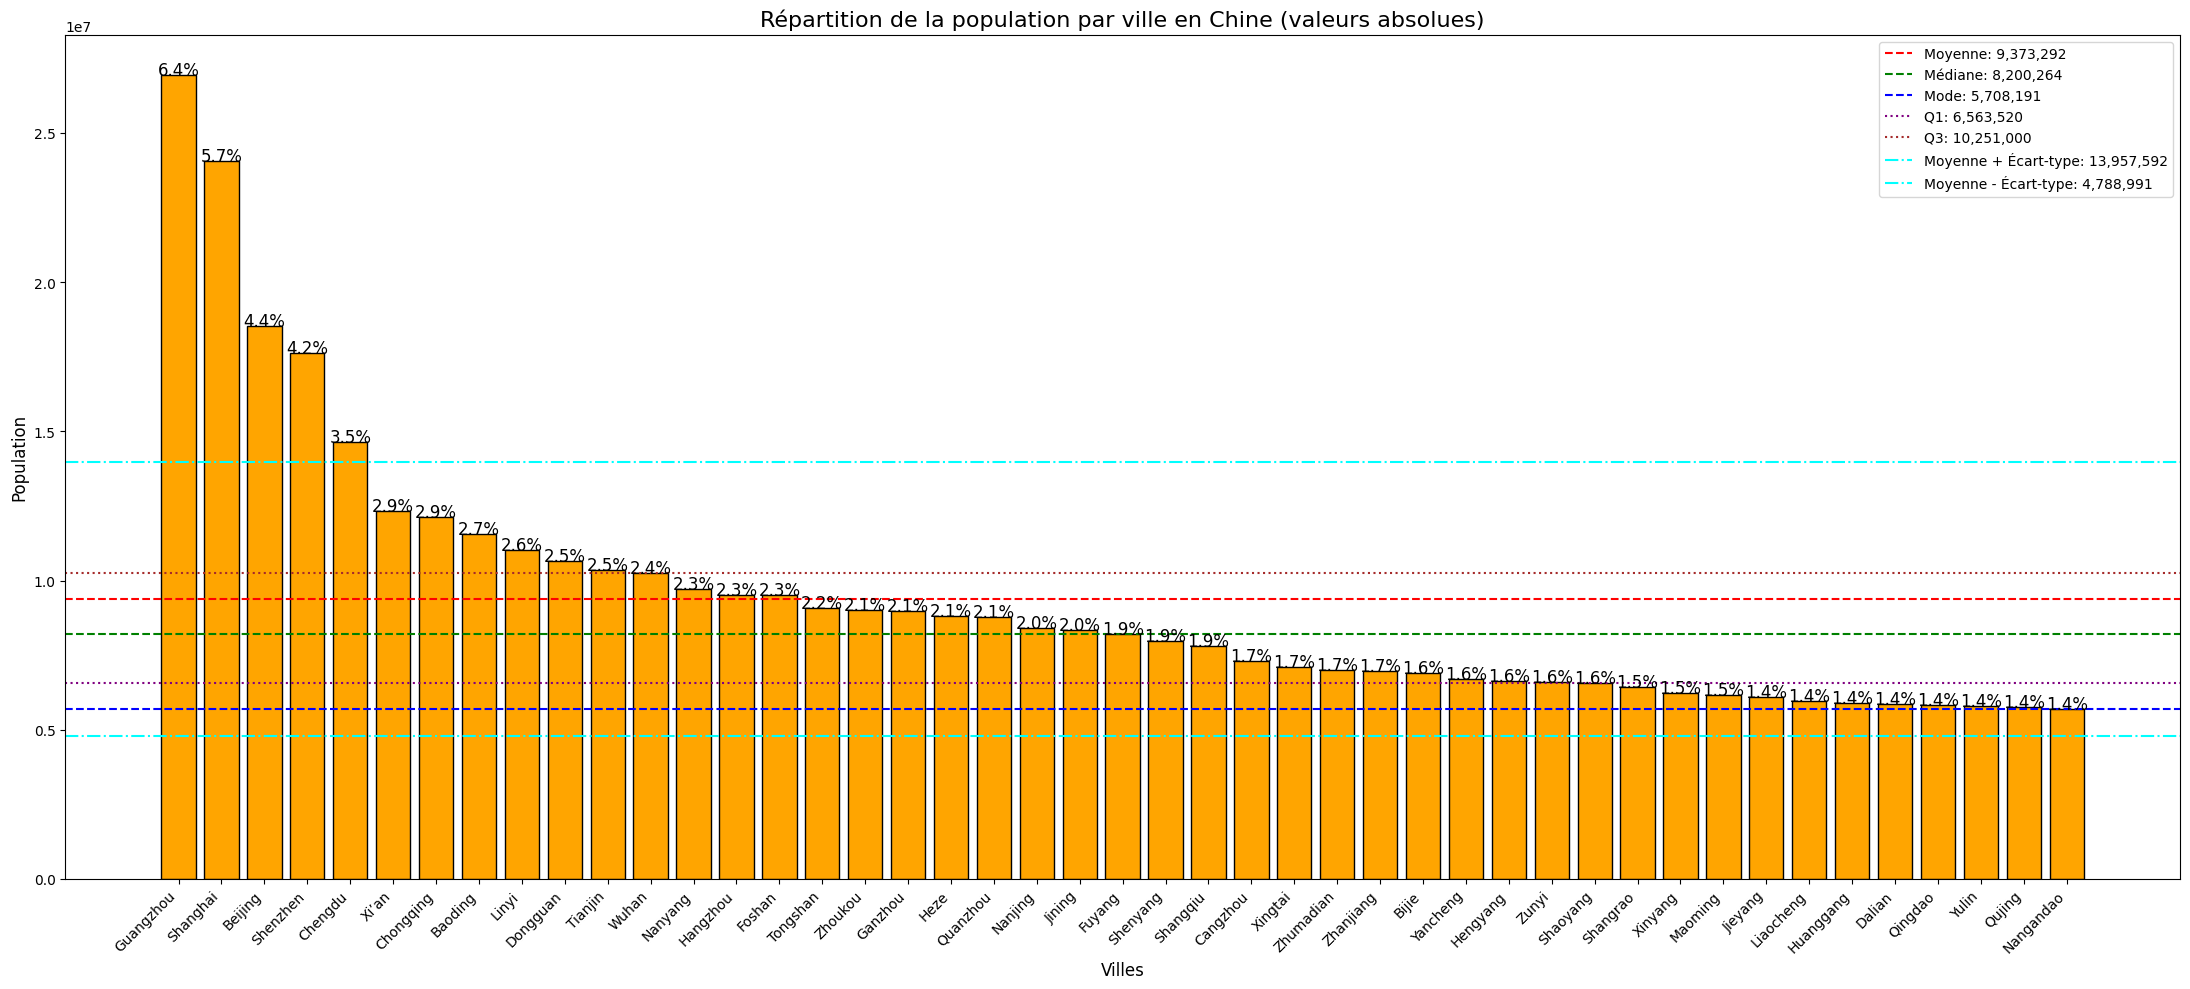

In [ ]:
# Filtrer les données pour inclure uniquement la Chine
data_chine = df[df['pays'] == 'China'].copy() # Créer une copie pour éviter les messages d'avertissements en exécutant

# Calculer la répartition en pourcentage de la population par ville
data_chine['pourcentage_population'] = ( # La population de chaque ville chinoise est divisée par la somme totale de la population de la Chine, puis multipliée par 100
    data_chine['population'] / data_chine['population'].sum() * 100
)

data_chine = data_chine.sort_values(by='population', ascending=False) # Trier les villes par population décroissante pour un affichage plus intuitif

# Calculer des statistiques descriptives
moyenne = data_chine['population'].mean() # Moyenne de la population
mediane = data_chine['population'].median() # Médiane de la population
mode = data_chine['population'].mode()[0] # Mode de la population
q1 = np.percentile(data_chine['population'], 25) # Premier quartile (Q1) : 25% de la population se trouve en dessous de cette valeur
q3 = np.percentile(data_chine['population'], 75) # Troisième quartile (Q3) : 75% de la population se trouve en dessous de cette valeur
ecart_type = data_chine['population'].std() # Écart-type de la population

# Création du graphique
plt.figure(figsize=(22, 10)) # Taille figure

# Création du diagramme à barres horizontales pour la population des villes
bars = plt.bar(
    data_chine['ville'],
    data_chine['population'],
    color='orange',
    edgecolor='black'
)

# Placer le texte du pourcentage au-dessus de chaque barre pour une meilleure visibilité
for bar, pct in zip(bars, data_chine['pourcentage_population']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Position horizontale du texte (au centre de chaque barre)
        bar.get_height() + 0.5,  # Position verticale du texte (au dessus de la barre)
        f"{pct:.1f}%",  # Afficher le pourcentage avec 1 décimale
        ha='center',  # Aligner horizontalement au centre
        fontsize=12,  # Taille de la police
        color='black'  # Couleur du texte
    )

# Tracer des lignes horizontales pour les statistiques calculées
plt.axhline(y=moyenne, color='red', linestyle='--', label=f"Moyenne: {moyenne:,.0f}") # Ligne pour la moyenne de la population
plt.axhline(y=mediane, color='green', linestyle='--', label=f"Médiane: {mediane:,.0f}") # Ligne pour la médiane de la population
plt.axhline(y=mode, color='blue', linestyle='--', label=f"Mode: {mode:,.0f}") # Ligne pour le mode de la population
plt.axhline(y=q1, color='purple', linestyle=':', label=f"Q1: {q1:,.0f}") # Ligne pour le premier quartile (Q1)
plt.axhline(y=q3, color='brown', linestyle=':', label=f"Q3: {q3:,.0f}") # Ligne pour le troisième quartile (Q3)
plt.axhline(y=moyenne + ecart_type, color='cyan', linestyle='-.', label=f"Moyenne + Écart-type: {moyenne + ecart_type:,.0f}") # Ligne pour la moyenne + écart-type
plt.axhline(y=moyenne - ecart_type, color='cyan', linestyle='-.', label=f"Moyenne - Écart-type: {moyenne - ecart_type:,.0f}") # Ligne pour la moyenne - écart-type

plt.title("Répartition de la population par ville en Chine (valeurs absolues)", fontsize=16)  # Titre graph
plt.ylabel("Population", fontsize=12)  # Titre axe y
plt.xlabel("Villes", fontsize=12)  # Titre axe x
plt.legend(loc='upper right', fontsize=10)  # Légende dans le coin droit en haut
plt.xticks(rotation=45, ha='right') # Rotation des étiquettes de l'axe des x pour les rendre plus lisibles

plt.tight_layout() # Optimisation de l'affichage pour éviter le chevauchement des éléments
plt.show() # Affiche la figure



---



Finalement, pour bien me préparer à l'étape suivante de géopandas dans la partie 3, j'utilise une heatmap qui représente l'emplacement des villes selon leur coordonnées géographique de latitude et de longitude. La grosseur des points représente la taille de la population (plus le point est gros, plus la population est peuplé). Pour bien différencier, la couleur des points représente aussi la densité de la population (plus le point se rapproche du rouge, plus la population est grande et plus il se rapproche du jaune, plus elle est petite)

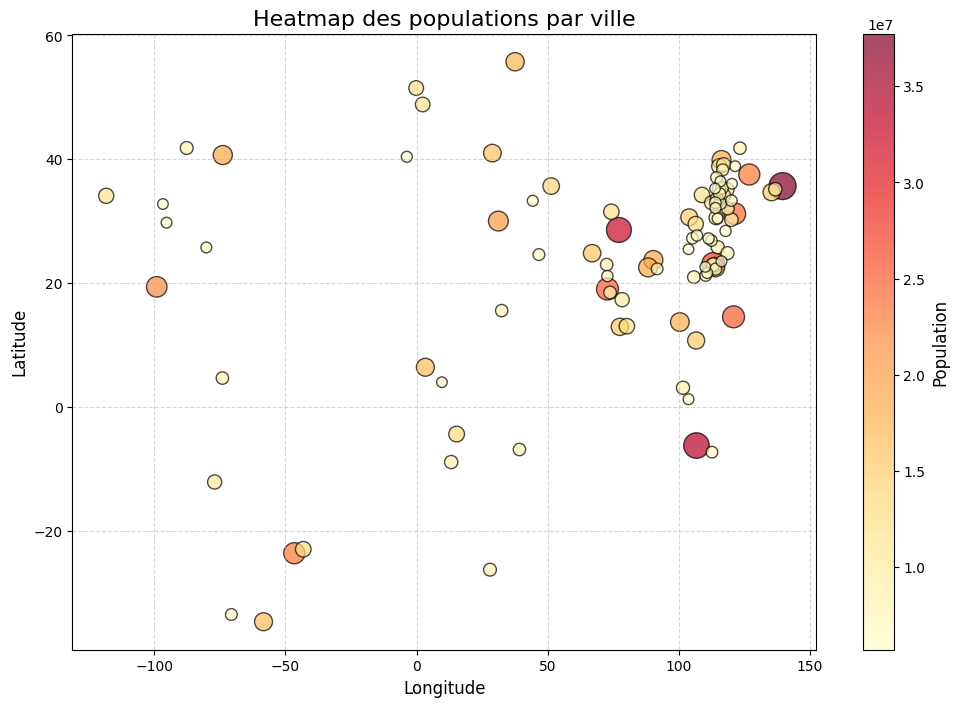

In [ ]:
# Préparer les données
data = df[['latitude', 'longitude', 'population']] # Sélection des attributs
latitudes = data['latitude']
longitudes = data['longitude']
populations = data['population']

# Création de la Heatmap
plt.figure(figsize=(12, 8))  # Taille de la figure

# Scatter plot avec tailles et couleurs basées sur la population
scatter = plt.scatter(
    x=longitudes, # Axe x
    y=latitudes, # Axe y
    c=populations, # Corrélation
    cmap='YlOrRd',  # Colormap pour couleur de la heatmap
    s=populations / 1e5,  # Taille des points
    alpha=0.7,  # Transparence des points
    edgecolor='k'  # Bordure noire pour les points
)

# Ajouter une barre de couleurs sur le côté pour référence
cbar = plt.colorbar(scatter)
cbar.set_label('Population', fontsize=12) # Titre

plt.title('Heatmap des populations par ville', fontsize=16) # Titre graph
plt.xlabel('Longitude', fontsize=12) # Titre axe x
plt.ylabel('Latitude', fontsize=12) # Titre axe y

# Afficher la heatmap
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Fin de la partie 1**

---



# **Début de la partie 2 : Analyse Géospatiale avec GeoPandas**

**Convertir le DataFrame Pandas en GeoDataFrame GeoPandas en utilisant les colonnes latitude et longitude.**

J'ai créée des objets Points avec les colonnes latitude et longitude. Geometry est la colonne contenant les objets Points. Chaque objet Point représente la latitude et longitude d'une ville. J'ai aussi utilisé le système de référence de coordonées (EPSG:4326) pour défénir un ensemble de coordonnées standard GPS (WGS84).

In [ ]:
# Créer la géométrie des points en utilisant les colonnes 'latitude' et 'longitude'
geometry = [Point(lon, lat) for lon, lat in zip(df['longitude'], df['latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry) # Convertir en GeoDataFrame (gdf)

# Définir un système de référence de coordonnées (CRS), ici WGS84 (utilisé pour les coordonnées GPS)
gdf.set_crs("EPSG:4326", allow_override=True, inplace=True)

print(gdf) # Afficher le gdf

        ville  latitude  longitude       pays  population  \
0       Tokyo   35.6897   139.6922      Japan  37732000.0   
1     Jakarta   -6.1750   106.8275  Indonesia  33756000.0   
2       Delhi   28.6100    77.2300      India  32226000.0   
3   Guangzhou   23.1300   113.2600      China  26940000.0   
4      Mumbai   19.0761    72.8775      India  24973000.0   
..        ...       ...        ...        ...         ...   
95    Qingdao   36.0669   120.3827      China   5818255.0   
96      Yulin   22.6540   110.1810      China   5796766.0   
97     Douala    4.0500     9.7000   Cameroon   5768400.0   
98     Qujing   25.4910   103.7960      China   5765775.0   
99  Nangandao   35.3036   113.9268      China   5708191.0   

                    geometry  
0   POINT (139.6922 35.6897)  
1    POINT (106.8275 -6.175)  
2        POINT (77.23 28.61)  
3       POINT (113.26 23.13)  
4    POINT (72.8775 19.0761)  
..                       ...  
95  POINT (120.3827 36.0669)  
96    POINT (110.18



---



**Charger un fichier shapefile contenant les frontières des pays.**

J'ai défini une fonction pour télécharger les fichiers .shp (shapefile) et .shx directement depuis Google Drive et les sauvegarder localement. Ensuite, j'ai converti le fichier pays.shp en un GéoDataFrame puis définis le CRS (EPSG:4326) du shapefile en WGS84, le même format que le .csv ci-haut. Ainsi, je peux proprement charger le shapefile et afficher son contenu renfermant les frontières des pays.  

In [ ]:
# Fonction pour télécharger un fichier depuis Google Drive en utilisant son ID
def download_file_from_google_drive(file_id, output_path):
    URL = f'https://drive.google.com/uc?id={file_id}' # Construire l'URL de téléchargement avec l'id du fichier
    response = requests.get(URL) # Effectuer une requête GET pour obtenir le contenu du fichier
    with open(output_path, 'wb') as f: # Ouvrir le fichier local en mode binaire pour pouvoir écrire le contenu téléchargé
        f.write(response.content)  # Sauvegarde le contenu téléchargé dans le bon fichier spécifié

shp_id = '1MTZ3dYHmSXdNHnxoDi3jyIe22Nl1bigu' # Id du fichier pays.shp
shx_id = '1xeafOWZCTRW1bZ3t1oYgMkFZOn-4tZGy' # Id du fichier pays.shx
shp_file_path = '/content/pays.shp' # Chemin local pour sauvegarder le fichier pays.shp
shx_file_path = '/content/pays.shx' # Chemin local pour sauvegarder le fichier pays.shx
download_file_from_google_drive(shp_id, shp_file_path) # Télécharger le fichier pays.shp
download_file_from_google_drive(shx_id, shx_file_path) # Télécharger le fichier pays.shx

pays_gdf = gpd.read_file(shp_file_path) # Lire le fichier pays.shp et le mettre dans un géodataframe(gdf)

pays_gdf.set_crs("EPSG:4326", allow_override=True, inplace=True) # Définir le système de référence de coordonnées (CRS) du shapefile en WGS84 (EPSG:4326)

print(pays_gdf) # Afficher les données du GeoDataFrame pour vérifier le contenu du shapefile


                                              geometry
0    MULTIPOLYGON (((117.70361 4.16341, 117.70361 4...
1    MULTIPOLYGON (((117.70361 4.16341, 117.69711 4...
2    MULTIPOLYGON (((-69.51009 -17.50659, -69.50611...
3    POLYGON ((-69.51009 -17.50659, -69.51009 -17.5...
4    MULTIPOLYGON (((-69.51009 -17.50659, -69.63832...
..                                                 ...
253  MULTIPOLYGON (((113.5586 22.16303, 113.56943 2...
254  POLYGON ((123.59702 -12.42832, 123.59775 -12.4...
255  POLYGON ((-79.98929 15.79495, -79.98782 15.796...
256  POLYGON ((-78.63707 15.86209, -78.64041 15.864...
257  POLYGON ((117.75389 15.15437, 117.75569 15.151...

[258 rows x 1 columns]




---



**Effectuer une jointure spatiale entre les villes et les frontières des pays pour déterminer dans quel pays se trouve chaque ville.**

Une jointure spatiale entre les villes (gdf) et les frontières des pays (pays_gdf) est implémenté ici. Une nouvelle colonne est ajouté au df, "geo_id" qui représente un id unique pour chaque pays. Par exemple, la chine à le id = 9.0. donc, toutes les villes contenue dans les frontières du pays de la chine vont avoir le même geo_id de 9.0. Les résultats sont ensuite affichés pour démontrer que la jointure à été un succès.  

In [ ]:
# La jointure de gauche associe chaque ville à un pays selon le critère "within" (la ville doit se trouver à l'intérieur des frontières du pays)
result = gpd.sjoin(gdf, pays_gdf, how='left', predicate='within')  # Jointure spatiale pour associer chaque ville à un pays

# Créer une nouvelle colonne 'geo_id' dans le df pour représenter l'identifiant du pays
# Index_right est la colonne ajoutée par la jointure et contient l'id du pays unique associé à chaque ville
result['geo_id'] = result['index_right']

correspondance = result[['ville', 'pays', 'geo_id', 'geometry']] # Afficher seulement les colonnes pertinentes pour s'assurer que la jointure spatiale s'est bien effectué

print(correspondance)  # Affiche les correspondances entre villes et pays

        ville       pays  geo_id                  geometry
0       Tokyo      Japan   189.0  POINT (139.6922 35.6897)
1     Jakarta  Indonesia     0.0   POINT (106.8275 -6.175)
2       Delhi      India     8.0       POINT (77.23 28.61)
3   Guangzhou      China     9.0      POINT (113.26 23.13)
4      Mumbai      India     8.0   POINT (72.8775 19.0761)
..        ...        ...     ...                       ...
95    Qingdao      China     9.0  POINT (120.3827 36.0669)
96      Yulin      China     9.0    POINT (110.181 22.654)
97     Douala   Cameroon   146.0          POINT (9.7 4.05)
98     Qujing      China     9.0    POINT (103.796 25.491)
99  Nangandao      China     9.0  POINT (113.9268 35.3036)

[100 rows x 4 columns]


**Fin partie 2**

---



# **Début de la partie 3 : Visualisation des Données**

**Visualiser les villes sur une carte en utilisant GeoPandas.**

**Colorer les points en fonction de la population des villes.**

**Visualiser les frontières des pays sur la même carte.**

Ici, à l'aide de GéoPandas, j'ai créée une carte du monde sur laquelle les villes dans le df vont apparaitre sous forme de points de couleur. Les couleurs de ses points sont reliés à la densité de la population de la ville. Dans les extrêmes, un point jaune pâle représente une faible population pour la ville et un point rouge foncé représente une population très dense pour la ville. Finalement, on peut clairement voir les frontières de chaque pays délimité par des tracés noir.    

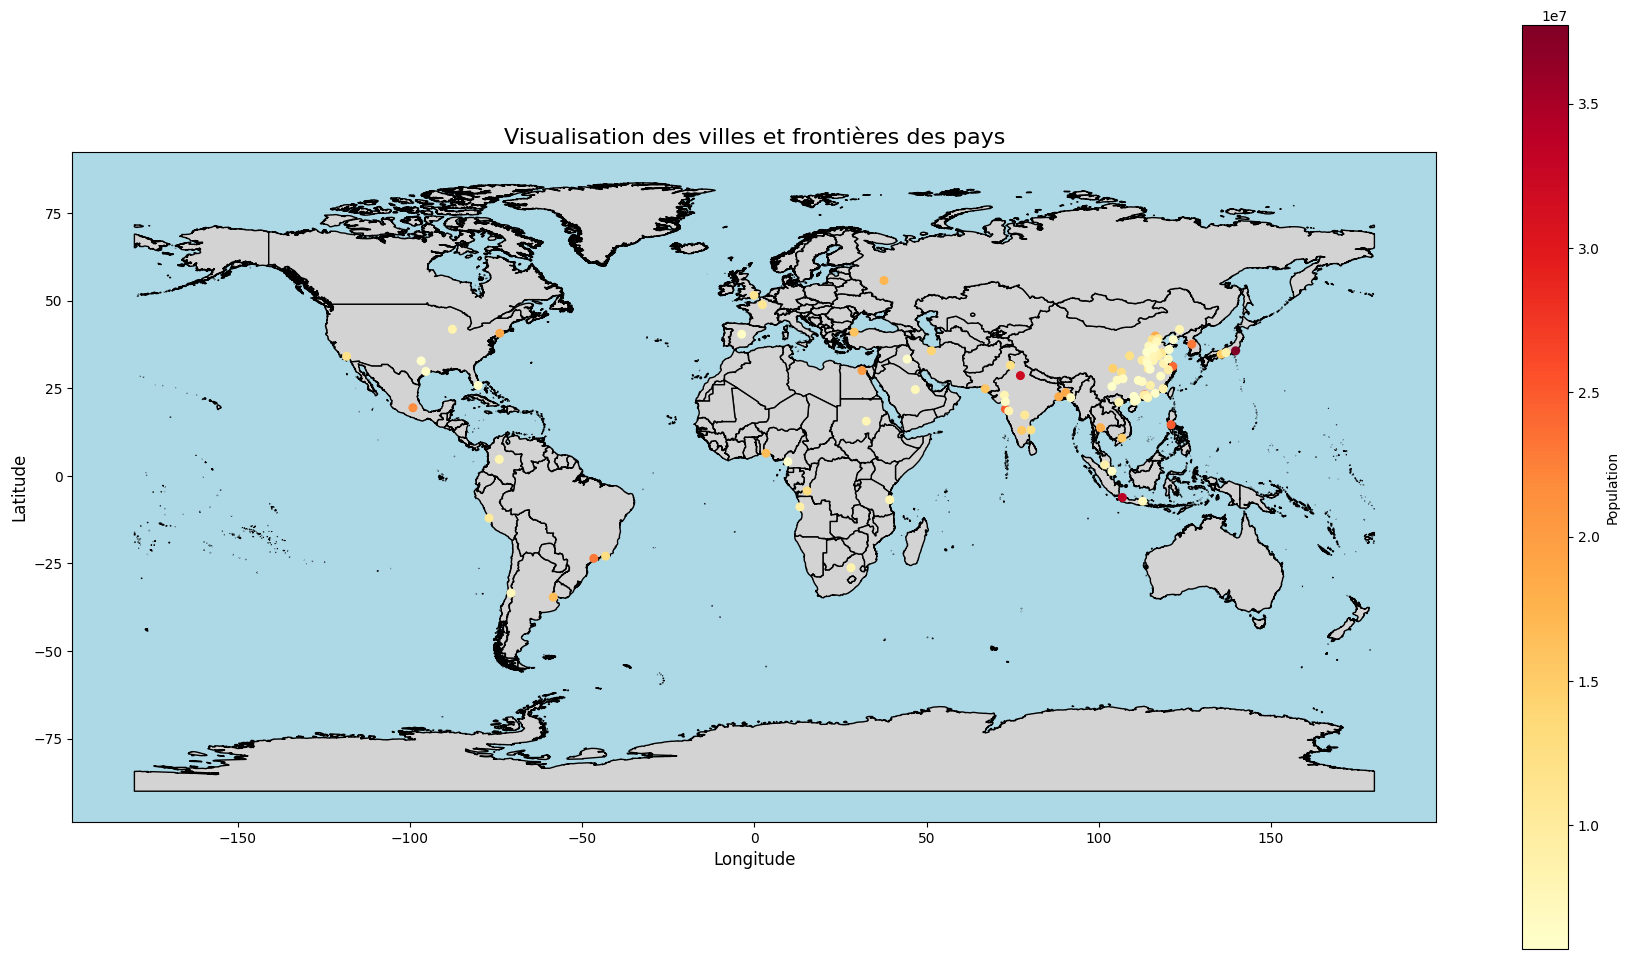

In [ ]:
ax = pays_gdf.plot(color='lightgrey', edgecolor='black', figsize=(22, 12))  # Permet l'ajout des frontières des pays
ax.set_facecolor('lightblue')  # Fond bleu clair ou il n'y a pas de continent pour représenter les océans

# Ajouter les villes sur la carte du monde et une couleur selon leur population
result.plot(column='population',
            cmap='YlOrRd',  # Le même colormap que dans la partie 1
            markersize=30,  # Augmente la taille des points pour mieux les voir sans trop éxagérer
            alpha=1,  # Pas de transparences des points
            ax=ax)  # Permet de superposer les points sur le même axe

# Créer une smap pour la colorbar sur le côté avec la même échelle que la population
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=result['population'].min(), vmax=result['population'].max()))
sm.set_array([])  # Nécessaire pour que la colorbar fonctionne
plt.colorbar(sm, ax=ax, label="Population") # Ajouter la colorbar à la carte

plt.title("Visualisation des villes et frontières des pays", fontsize=16) # Titre de la carte
plt.xlabel("Longitude", fontsize=12) # Titre axe des x
plt.ylabel("Latitude", fontsize=12) # Titre axe des y
plt.show() # Afficher la carte

**Fin partie 3**

---



# **Début de la partie 4 : Tests Unitaires**

**Écrire des tests unitaires pour vérifier les fonctions de manipulation des données.**

Cette section effectue les test unitaires sur les fonctions qui manipule les données. Ce code garantit que le DataFrame téléchargé contient des données valides et cohérentes, en effectuant plusieurs vérifications comme la gestion des valeurs manquantes, la validation des coordonnées géographiques, et la détection des doublons. Il y a un total de 10 tests, et ceux-ci s'exécute sans lever d'erreur.

In [ ]:
class TestUnitaireManipulation(unittest.TestCase):

    @classmethod
    def setUpClass(cls):
        # Identifiant réel du fichier Google Drive
        file_id = '1Oytomiaxf4n3JvX0JMYtw9GUcbZ3S98d'
        # Génère un lien direct pour télécharger le fichier à partir de Google Drive
        direct_link = f'https://drive.google.com/uc?id={file_id}'

        try:
            # Effectue une requête GET pour télécharger le fichier à partir du lien généré
            response = requests.get(direct_link)
            response.raise_for_status()  # Vérifie si la requête a réussi
            data = response.content.decode('utf-8')
            # Charge les données dans un DataFrame Pandas
            cls.df = pd.read_csv(StringIO(data))
        except requests.exceptions.RequestException as e:
            # Affiche un message d'erreur si la requête échoue
            print(f"Erreur lors du téléchargement du fichier : {e}")
            cls.df = None  # Définit le DataFrame à None en cas d'erreur

    def test_fichier_telecharger_succes(self):
        # Vérifie que le DataFrame est correctement téléchargé
        self.assertIsNotNone(self.df, "Le téléchargement du fichier a échoué, DataFrame est vide.")

    def test_fichier_telecharger_echec(self):
        # Simule le téléchargement d'un fichier inexistant avec un identifiant invalide
        invalide_id_fichier = 'INVALIDE_ID'
        # Génère un lien direct avec un identifiant invalide
        lien_invalide = f'https://drive.google.com/uc?id={invalide_id_fichier}'

        try:
            # Essaye de télécharger le fichier à partir du lien invalide
            response = requests.get(lien_invalide)
            response.raise_for_status()  # Cette étape devrait échouer
        except requests.exceptions.RequestException as e:
            # Vérifie que l'exception levée est bien une exception de type RequestException
            self.assertIsInstance(e, requests.exceptions.RequestException, "L'exception levée n'est pas du bon type.")

    def test_valeurs_manquantes(self):
        # Calcul des valeurs manquantes dans le DataFrame
        valeurs_manquantes = self.df.isna().sum().sum()  # Somme totale des valeurs manquantes
        # Vérifie qu'il n'y a aucune valeur manquante dans le DataFrame
        self.assertEqual(valeurs_manquantes, 0, "Le DataFrame contient des valeurs manquantes.")

    def test_correction_valeurs_manquantes(self):
        # Applique les corrections à une ligne spécifique contenant des données mal formatées
        ligne_a_corriger = 8
        corrections = {
            "ville": "Seoul",
            "latitude": 37.5600,
            "longitude": 126.9900,
            "pays": "Korea, South",
            "population": 23016000
        }
        # Appliquer les corrections
        self.df.loc[ligne_a_corriger, corrections.keys()] = corrections.values()

        # Vérification que les valeurs ont été correctement corrigées, sinon identifies les erreurs
        ligne_corrigee = self.df.loc[ligne_a_corriger]
        for col, value in corrections.items():
            self.assertEqual(ligne_corrigee[col], value, f"Correction échouée pour la colonne {col}.")

    def test_doublons(self):
        # Test si le DataFrame contient des doublons
        duplicats = self.df[self.df.duplicated()]  # Filtre les lignes en doublon
        # Vérifie qu'il n'y a aucun doublon dans le df, sinon les identifies
        self.assertTrue(duplicats.empty, f"Le DataFrame contient des doublons :\n{duplicats.index.tolist()}")

    def test_latitude(self):
        # Test si la latitude est dans la plage valide (-90, 90)
        latitudes_invalide = self.df[(self.df['latitude'] < -90) | (self.df['latitude'] > 90)]
        # Vérifie qu'il n'y a aucune latitude en dehors de la plage valide, sinon les identifies
        self.assertTrue(
            latitudes_invalide.empty,
            f"Certaines latitudes sont hors de la plage valide (-90 à 90) :\n{latitudes_invalide.index.tolist()}"
        )

    def test_longitude(self):
        # Test si la longitude est dans la plage valide (-180, 180)
        longitude_invalide = self.df[(self.df['longitude'] < -180) | (self.df['longitude'] > 180)]
        # Vérifie qu'il n'y a aucune longitude en dehors de la plage valide, sinon les identifies
        self.assertTrue(
            longitude_invalide.empty,
            f"Certaines longitudes sont hors de la plage valide (-180 à 180) :\n{longitude_invalide.index.tolist()}"
        )

    def test_population(self):
        # Test si la population est supérieure à un seuil minimum (5000)
        population_invalide = self.df[self.df['population'] <= 5000]
        # Vérifie qu'il n'y a aucune population en dessous du seuil minimum, sinon les identifies
        self.assertTrue(
            population_invalide.empty,
            f"Certaines populations sont en dessous du seuil minimum (5000) :\n{population_invalide.index.tolist()}"
        )

    def test_pays(self):
        # Test la fréquence des pays dans le df
        nbr_pays = self.df['pays'].value_counts()
        # Vérifie qu'il y a au moins un pays présent dans les données
        self.assertGreater(len(nbr_pays), 0, "Aucun pays valide trouvé dans le DataFrame.")

    def test_villes(self):
        # Test si des villes apparaissent plus d'une fois
        villes_double = self.df['ville'].value_counts()[self.df['ville'].value_counts() > 1]
        # Vérifie qu'aucune ville n'apparaît plusieurs fois, sinon les identifies
        self.assertTrue(villes_double.empty, f"Certaines villes apparaissent plusieurs fois : {villes_double.index.tolist()}")

if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)


..........
----------------------------------------------------------------------
Ran 10 tests in 2.583s

OK




---



**Écrire des tests unitaires pour vérifier les fonctions de jointure spatiale.**

Cette section effectue les test unitaires sur les fonctions qui sont liés à la jointure spatiale. Ce code garantit que les fichiers pays.shp et pays.shx sont bien téléchargés. Ensuite je m'assure que les manipulations effectuées ont été un succès (la conversion du CRS, la jointure spatiale et l'ajout de la colonne geo_id). Il y a un total de 7 tests, et ceux-ci s'exécute tous sans lever d'erreur ou d'anomalie.

In [ ]:
class TestUnitaireJointure(unittest.TestCase):

    @classmethod
    def setUpClass(cls):
        # Chemin et id pour les fichiers hébérgés sur mon Google Drive
        cls.shp_id = '1MTZ3dYHmSXdNHnxoDi3jyIe22Nl1bigu'
        cls.shx_id = '1xeafOWZCTRW1bZ3t1oYgMkFZOn-4tZGy'
        cls.shp_file_path = '/content/pays.shp'
        cls.shx_file_path = '/content/pays.shx'

        # Télécharger les fichiers depuis mon Google Drive
        download_file_from_google_drive(cls.shp_id, cls.shp_file_path)
        download_file_from_google_drive(cls.shx_id, cls.shx_file_path)

    def test_fichier_shp_succes(self):
        # Test si le fichier pays.shp est bien téléchargé et lisible
        try:
            gdf = gpd.read_file(self.shp_file_path)
            self.assertIsInstance(gdf, gpd.GeoDataFrame, "Le fichier pays.shp n'a pas pu être téléchargé en tant que gdf.")
        except Exception as e:
            self.fail(f"Erreur lors du chargement du fichier pays.shp : {e}")

    def test_fichier_shp_echec(self):
        # Test qu'une erreur est levé si le fichier pays.shp est invalide
        mauvais_fichier = 'path/to/invalid/file.shp'
        with self.assertRaises(Exception, msg="Aucune exception levée pour un fichier .shp invalide."):
            gpd.read_file(mauvais_fichier)

    def test_telechargement_shx_succes(self):
        # Test si le fichier pays.shx est bien téléchargé et lisible
        try:
            with open(self.shx_file_path, 'rb') as file:
                data = file.read()
            self.assertTrue(data, "Le fichier pays.shx est vide ou n'a pas pu être lu.")
        except FileNotFoundError:
            self.fail("Le fichier pays.shx est introuvable.")

    def test_telechargement_shx_echec(self):
        # Test qu'une erreur est levé si le fichier pays.shx est invalide
        mauvais_fichier = 'path/to/invalid/file.shx'
        with self.assertRaises(FileNotFoundError, msg="Aucune exception levée pour un fichier .shx invalide."):
            with open(mauvais_fichier, 'rb') as file:
                file.read()

    def test_crs_correct(self):
        # Test que le CRS du gdf est correctement défini en EPSG:4326
        try:
            gdf = gpd.read_file(self.shp_file_path)
            gdf.set_crs("EPSG:4326", allow_override=True, inplace=True)
            self.assertEqual(gdf.crs.to_string(), "EPSG:4326", "Le CRS n'a pas été correctement défini.")
        except Exception as e:
            self.fail(f"Erreur lors de la vérification du CRS : {e}")

    def test_jointure_spatiale(self):
        # Test si la jointure spatiale entre les villes et les frontières des pays a été bien effectué
        try:
            # Effectuer la jointure spatiale (join de type gauche avec within)
            result = gpd.sjoin(gdf, pays_gdf, how='left', predicate='within')

            # Vérifier si la jointure a produit des résultats ou non
            self.assertFalse(result.empty, "La jointure spatiale n'a pas produit de résultats.")
            self.assertIn('index_right', result.columns, "La colonne index_right n'est pas présente après la jointure.")

        except Exception as e:
            self.fail(f"Erreur lors de la jointure spatiale : {e}")

    def test_ajout_geo_id(self):
        # Test que l'ajout de geo_id fonctionne correctement
        try:
            # Ajouter la colonne geo_id qui contient l'index du pays (index_right)
            result['geo_id'] = result['index_right']

            # Vérifier si la colonne geo_id a été correctement ajoutée
            self.assertIn('geo_id', result.columns, "La colonne geo_id n'a pas été ajoutée au gdf.")

        except Exception as e:
            self.fail(f"Erreur lors de la tentative de l'ajout de l'identifiant géographique : {e}")

if __name__ == "__main__":
    # Lancer les tests unitaires
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

.................
----------------------------------------------------------------------
Ran 17 tests in 9.081s

OK


**Fin partie 4**

---

